# Importing dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS  = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

import pickle
import regex as re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shree\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Exploratory Data Analysis

In [4]:
## Loading dataset
data = pd.read_csv('amazon_alexa.tsv', delimiter='\t', quoting=3)

print("Dataset loaded successfully!")
print(data.shape)

Dataset loaded successfully!
(3150, 5)


In [5]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [ ]:
## Columns in the dataset
data.columns

array(['rating', 'date', 'variation', 'verified_reviews', 'feedback'],
      dtype=object)

In [11]:
## Checking for missing values
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [17]:
data[data['verified_reviews'].isnull()]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [18]:
## Droping the null value row
data = data.dropna(subset=['verified_reviews'])

In [19]:
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

In [20]:
## Creating a new column 'length' to store the length of each review
data['length'] = data['verified_reviews'].apply(len)

data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [21]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

In [22]:
len(data)

3149

In [25]:
## Distinct values in the rating column
data['rating'].value_counts()

rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64

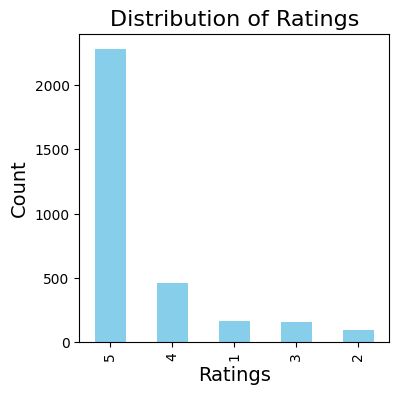

In [31]:
## Bar plot for ratings
plt.figure(figsize=(4,4))
data['rating'].value_counts().plot.bar(color='skyblue')
plt.title('Distribution of Ratings', fontsize=16)
plt.xlabel('Ratings', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

In [34]:
## Percentage of each rating, roudinged to 2 decimal places

(data['rating'].value_counts(normalize=True) * 100).round(2)


rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: proportion, dtype: float64

In [35]:
## analysis of feedback column
data['feedback'].value_counts()

feedback
1    2893
0     256
Name: count, dtype: int64

In [56]:
## Understating the feedback == 1 means
data[data['feedback'] == 1].iloc[0]['verified_reviews']


'Love my Echo!'

In [ ]:
 ## understading the feedback == 0 means
data[data['feedback'] == 0].iloc[3]['verified_reviews']


'"Stopped working after 2 weeks ,didn\'t follow commands!? Really fun when it was working?"'

In [58]:
## 'Feedback' == 1 means positive review, 'Feedback' == 0 means negative review

In [63]:
## Relating 'rating' with 'feedback'

data.groupby('rating')['feedback'].value_counts()

rating  feedback
1       0            161
2       0             95
3       1            152
4       1            455
5       1           2286
Name: count, dtype: int64

In [64]:
## rating 1 and 2 mostly have feedback 0 (negative review)
## rating 3, 4 and 5 mostly have feedback 1 (positive review)


In [65]:
## analysing the 'varaiation' column
data['variation'].value_counts()

variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64

## Going with the NLP part

In [66]:
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(data['verified_reviews'])

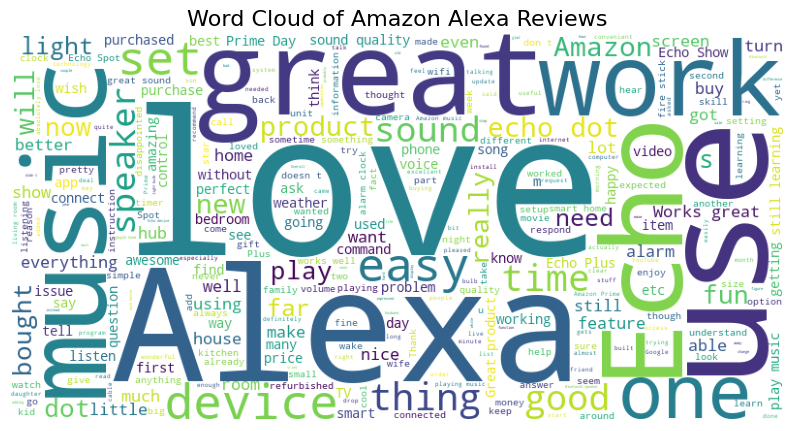

In [68]:
##  combine all reviews to create a single string

all_reviews = ' '.join([review for review in data['verified_reviews']])

## Initialize WordCloud object
wc = WordCloud(background_color='white', width=800, height=400, max_words=300)

## generate and plot word cloud 
plt.figure(figsize=(10,6))
plt.imshow(wc.generate(all_reviews))
plt.title('Word Cloud of Amazon Alexa Reviews', fontsize=16)
plt.axis('off')
plt.show()